In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
import matplotlib.pyplot as plt
from IPython.display import Math, display

In [2]:
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)

df = pd.concat([X, y.rename("class")], axis=1)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
def gini(groups, classes):
    total_samples = sum([len(group) for group in groups])
    gini_value = 0.0
    
    for group in groups:
        size = len(group)
        if size == 0:
            continue
        score = 0.0
        for c in classes:
            p = (group == c).sum() / size
            score += p ** 2
        gini_value += (1 - score) * (size / total_samples)
        
    return gini_value

In [4]:
threshold = 5.5
left = y[X["sepal length (cm)"] <= threshold]
right = y[X["sepal length (cm)"] > threshold]

g = gini([left, right], classes=[0,1,2])
g

0.44862482150617744

In [5]:
best_feature = None
best_thresh = None
best_gini = 999

for col in X.columns:
    values = sorted(X[col].unique())
    thresholds = [(values[i] + values[i+1]) / 2 for i in range(len(values)-1)]
    
    for t in thresholds:
        left = y[X[col] <= t]
        right = y[X[col] > t]
        g = gini([left, right], classes=[0,1,2])
        
        if g < best_gini:
            best_gini = g
            best_feature = col
            best_thresh = t

best_feature, best_thresh, best_gini

('petal length (cm)', 2.45, 0.3333333333333333)

In [6]:
display(Math(r"Gini = 1 - \sum p_i^2"))
display(Math(r"Gini\ Split = \sum \frac{N_{group}}{N_{total}} (1 - \sum p^2)"))
display(Math(fr"Best\ Split: {best_feature} < {best_thresh:.2f},\ Gini = {best_gini:.4f}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [7]:
model = DecisionTreeClassifier(criterion="gini")
model.fit(X, y)

DecisionTreeClassifier()

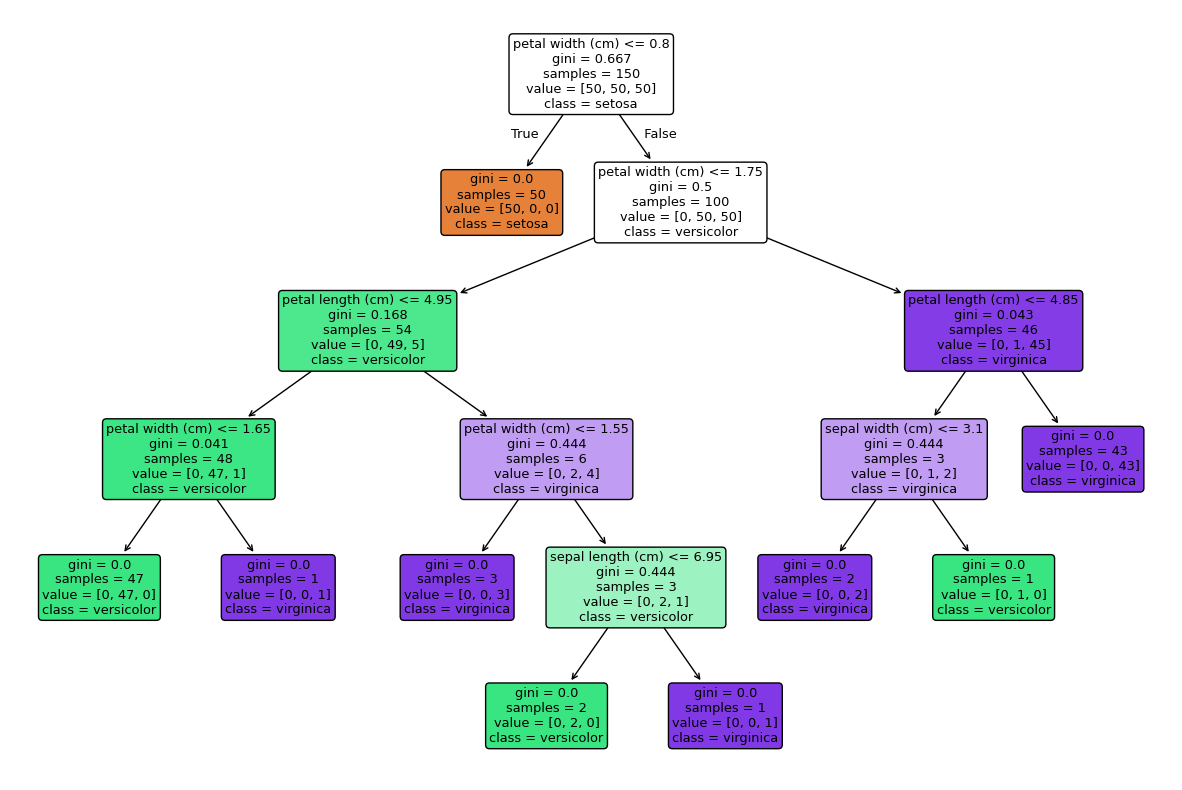

In [8]:
plt.figure(figsize=(15,10))
plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True
)
plt.show()

In [9]:
tree_rules = export_text(model, feature_names=list(X.columns))
print(tree_rules)

|--- petal width (cm) <= 0.80
|   |--- class: 0
|--- petal width (cm) >  0.80
|   |--- petal width (cm) <= 1.75
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- petal width (cm) <= 1.65
|   |   |   |   |--- class: 1
|   |   |   |--- petal width (cm) >  1.65
|   |   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- petal width (cm) <= 1.55
|   |   |   |   |--- class: 2
|   |   |   |--- petal width (cm) >  1.55
|   |   |   |   |--- sepal length (cm) <= 6.95
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- sepal length (cm) >  6.95
|   |   |   |   |   |--- class: 2
|   |--- petal width (cm) >  1.75
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- sepal width (cm) <= 3.10
|   |   |   |   |--- class: 2
|   |   |   |--- sepal width (cm) >  3.10
|   |   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2



In [10]:
pred = model.predict(X)

from sklearn.metrics import accuracy_score
acc = accuracy_score(y, pred)

display(Math(fr"Akurasi\ Model\ (sklearn): {acc:.4f}"))

<IPython.core.display.Math object>